# 5장 1강: 배깅과 랜덤포레스트

## 실습 목표
이번 실습에서는 **Ames Housing** 데이터를 이용하여 배깅과 랜덤포레스트의 핵심 원리를 확인합니다.

- 하나의 의사결정나무와 여러 나무를 모은 배깅의 차이를 확인합니다.
- 배깅에서 여러 회귀 모델의 예측을 평균내는 이유를 이해합니다.
- 랜덤포레스트의 부트스트랩과 피처 무작위 선택 개념을 확인합니다.
- OOB Score와 Feature Importance를 확인합니다.
- 여러 나무를 평균낼 때 분산이 줄어드는 이유를 설명합니다.

> 교안에 나온 범위만 사용합니다.

## 실습 환경 / 데이터
- Python, pandas, numpy, matplotlib, scikit-learn
- 데이터: `Ames_Housing.csv`
- 예측 대상: `SalePrice`

사용 특성:
`OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF`, `1stFlrSF`,
`2ndFlrSF`, `FullBath`, `TotRmsAbvGrd`, `YearBuilt`, `YearRemodAdd`, `Fireplaces`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import r2_score

house = pd.read_csv("Ames_Housing.csv")

features = [
    "OverallQual","GrLivArea","GarageCars","GarageArea",
    "TotalBsmtSF","1stFlrSF","2ndFlrSF","FullBath",
    "TotRmsAbvGrd","YearBuilt","YearRemodAdd","Fireplaces"
]

X = house[features]
y = house["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
display(X.isna().sum().to_frame("missing"))

Train: (1168, 12)
Test: (292, 12)


,missing
OverallQual,0
GrLivArea,0
GarageCars,0
GarageArea,0
TotalBsmtSF,0
1stFlrSF,0
2ndFlrSF,0
FullBath,0
TotRmsAbvGrd,0
YearBuilt,0


In [2]:
# 앙상블: 여러 모델의 예측을 결합하여 하나의 최종 예측을 만드는 방법
# 대표적인 모델: Tree형 모델(RandomForest), 배깅

# 배깅: Bootstrap으로 만든 여러 표본에 각각 모델을 학습시키고 예측을 결합하는 앙상블 방법
# -> 고객 1,000명 데이터에서 여러 학습 표본을 만들고, 각 표본으로 모델이 학습하여, 예측 결과를 결합하는 것

# 랜덤포레스트(RF, rf, Rf): 여러 의사결정 나무를 학습하고 각 분할에서 특성 후보를 무작위로 고르는 방식을 활용, 예측을 결합하는 모델
# -> 주택 가격을 예측할 떄, 나무 A는 면적을 중심으로, 나무 B는 위치를 중심으로 분할할 수 있다.

# OOB : 여러 결정 트리를 만들 때 각 트리가 학습할 데이터를 중복을 허용해서 무작위로 뽑는 과정에서(복원추출) 어떤 데이터들은 여러번 뽑히고
# 어떤 데이터는 한번도 안 뽑힌다면 한 번도 안 뽑힌 데이터를 OOB라고 부른다(Out Of Bag)

# OOB-Score : 1을 예측할 때 1을 학습하지 않은 데이터만 모아서 학습하는데 예측 결과와 실제 정답을 비교하여 계산한 점수가 OOB-Score이다.
# -> 학습하지 않은 데이터를 얼마나 잘 예측할 수 있는가?



# 필수 1. 하나의 나무와 Bagging 비교

## 문제 1. Decision Tree 하나를 학습하세요.
1. `DecisionTreeRegressor(random_state=42)` 사용
2. Train 학습
3. Train/Test 예측
4. Train R², Test R² 계산
5. 두 점수 차이 해석

In [3]:
# TODO
# 1. DecisionTreeRegressor 모델 생성 (깊이 제한 없음)
dt = DecisionTreeRegressor(random_state=42)

# 2. Train 데이터 학습
dt.fit(X_train, y_train)

# 3. Train 및 Test 예측
y_train_pred_dt = dt.predict(X_train)
y_test_pred_dt = dt.predict(X_test)

# 4. Train R², Test R² 계산
train_r2_dt = r2_score(y_train, y_train_pred_dt)
test_r2_dt = r2_score(y_test, y_test_pred_dt)
gap_dt = train_r2_dt - test_r2_dt

print("=== 단일 Decision Tree Regressor 결과 ===")
print(f"Train R² Score : {train_r2_dt:.4f}")
print(f"Test R² Score  : {test_r2_dt:.4f}")
print(f"Train-Test Gap : {gap_dt:.4f}")

=== 단일 Decision Tree Regressor 결과 ===
Train R² Score : 0.9999
Test R² Score  : 0.7939
Train-Test Gap : 0.2060


###
- Tree = DecisionTreeRegressor(random_state=42): 깊이를 제한하지 않은 회귀나무
- max_depth를 지정하지 않았기 때문에 무한하게 학습을 할 수도 있겠다라고 판단할 수 있지만 더 나눌 수 없거나 기본 분할 조건을 만족하지 못하면 멈춘다.
###
- Train이 1에 가깝다는 것의 의미: 일반적으로 R²이 1에 가깝다는 것은 모델이 충분히 해당 데이터에 대한 설명력을 가지고 있다는 것이지만
- 지나치게 성능이 높은 경우 과적합 위험을 의심하여 추가적인 검증이 필요하다.

### Q1. Train R²는 매우 높은데 Test R²가 더 낮다면 무엇을 의미하나요?

**답변:** 과적합 가능성이 높다.
- 이는 나무가 학습 데이터 변화에 민감한, 분산이 큰 모델임을 보여준다.
- Decision Tree의 한 그루는 불안정할 수 있다.

## 문제 2. Bagging을 적용하세요.
1. 기본 모델은 `DecisionTreeRegressor(random_state=42)`
2. `BaggingRegressor`
3. `n_estimators=50`
4. `random_state=42`
5. Test R² 계산
6. `max_features="sqrt`
7. Decision Tree 하나와 비교

In [4]:
# TODO
import numpy as np
import pandas as pd
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeRegressor

# 전체 특성 수(12개)의 제곱근 계산: int(np.sqrt(12)) -> 3
n_features_sqrt = int(np.sqrt(X_train.shape[1]))

# 1~4, 6. BaggingRegressor 생성 (max_features에 정수값 전달)
bagging = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=50,
    max_features=n_features_sqrt,  # 'sqrt' 문자열 대신 계산된 정수 3 전달
    random_state=42,
)

# Train 데이터 학습
bagging.fit(X_train, y_train)

# 5. Train 및 Test 예측 및 R² 계산
y_train_pred_bag = bagging.predict(X_train)
y_test_pred_bag = bagging.predict(X_test)

train_r2_bag = r2_score(y_train, y_train_pred_bag)
test_r2_bag = r2_score(y_test, y_test_pred_bag)

# 7. 단일 결정트리와 성능 비교
comparison_bag = pd.DataFrame(
    {
        "모델": ["단일 Decision Tree", "Bagging (50개 나무)"],
        "Train R²": [train_r2_dt, train_r2_bag],
        "Test R²": [test_r2_dt, test_r2_bag],
        "Train-Test Gap": [
            train_r2_dt - test_r2_dt,
            train_r2_bag - test_r2_bag,
        ],
    }
)

print("=== 단일 결정트리 vs Bagging 성능 비교 ===")
display(
    comparison_bag.style.format(
        {"Train R²": "{:.4f}", "Test R²": "{:.4f}", "Train-Test Gap": "{:.4f}"}
    )
)

=== 단일 결정트리 vs Bagging 성능 비교 ===


,모델,Train R²,Test R²,Train-Test Gap
0,단일 Decision Tree,0.9999,0.7939,0.2060
1,Bagging (50개 나무),0.9585,0.8608,0.0978


### 배깅, 나무 50개를 평균한다는 것의 의미
- 어떤 트리가 특정 주택을 높게 예측하고 다른 트리가 낮게 예측하면 평균에서 오류가 일부 상쇄될 수 있다.
- 다만, 여러 트리가 모두 같은 방향으로 크게 틀리는 경우, 평균을 해도 오류가 남는다.
- 따라서 무조건 모델 수만 늘리면 오류를 해결할 수 있는 것은 아니다.

### Q2. 왜 각 나무를 서로 다른 부트스트랩 샘플로 학습하나요?

**답변:**
- 완전히 같은 데이터로 여러 나무를 구성하게 되면 모델이 비슷한 학습을 보이기 때문에 앙상블 효과가 적어짐
- 부트스트랩으로 학습 데이터셋을 조금씩 바꾸면 나무마다 다른 오류 패턴을 학습하고 평균을 내는 과정에서 오류가 일부 상쇄될 가능성이 있음.

## 필수 2. Random Forest의 OOB Score와 Feature Importance

### 문제 1. OOB Score를 확인하세요.
1. `RandomForestRegressor`
2. `n_estimators=100`
3. `bootstrap=True`
4. `oob_score=True`
5. `random_state=42`
6. Test R²와 `oob_score_` 출력

In [5]:
# TODO
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1~5. RandomForestRegressor 모델 생성 및 OOB Score 활성화
rf = RandomForestRegressor(
    n_estimators=100,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1,
)

# Train 데이터 학습
rf.fit(X_train, y_train)

# 6. Test 예측 및 R² 점수, oob_score_ 계산
y_test_pred_rf = rf.predict(X_test)
test_r2_rf = r2_score(y_test, y_test_pred_rf)
oob_score_rf = rf.oob_score_

print("=== Random Forest 평가 결과 ===")
print(f"OOB R² Score : {oob_score_rf:.4f}")
print(f"Test R² Score: {test_r2_rf:.4f}")

=== Random Forest 평가 결과 ===
OOB R² Score : 0.8190
Test R² Score: 0.8901


###
- 각 Train 표본의 OOB 예측을 따로 모은다.
- 어떤 Train 주택 A를 예측할 때 A를 한 번도 뽑지 않은 나무들만 사용한다.
- 1, 4, 7번 나무가 A를 학습하지 않았다면 A의 예측 평균을 사용한다.
###
- Test R²은 0.89: 별도 100개 나무의 전체 평균
- OOB Score: 각 Train 표본을 학습하지 않은 나무들의 표본 예측 결과
- OOB 계산식
- $$P(\mathrm{OOB}) = \left(1-\frac1N\right)^\approx e^{-1}\approx0.368$$
###
- OOB가 0.83이라는 것의 의미
- OOB 예측의 제곱오차 합이 Train 실제 평균 가격을 예측하는 기준보다 83%정도 작다.
- OOB 지표도 음수가 될 수 있다.
###
- 별도 검증이나 교차검증을 대체할 수 있는가?
- OOB는 부트스트랩 학습의 남은 데이터셋을 이용하므로 Train / Validation 분할없이 모델을 점검하는 데 편리하다.
- 목적에 맞는 데이터셋과 설계에 따라 검증이나 교차검증이 추가적으로 필요한 경우들이 있다.
- 독립적인 결과로 해석하는 경우는 적다.

#### Q3. OOB 샘플은 무엇인가요?

**답변:** 모델이 학습에 한 번도 사용하지 않은 데이터 모음집
- 부트스트랩 샘플링에서 한 번도 선택되지 않은 데이터

#### Q4. OOB Score가 교차검증을 완전히 대체하나요?

**답변:** 아니오.
- OOB는 편리한 추정치를 산출하지만 데이터가 적은 상황, 더 높은 신뢰도가 필요한 상황이라면 교차검증과 함께 쓰이는 것이 일반적이다.

## 문제 2. Feature Importance를 확인하세요.
1. `feature_importances_` 사용
2. 특성명과 중요도 DataFrame 생성
3. 내림차순 정렬
4. 막대그래프
5. 가장 높은 중요도 특성 확인

=== 특성 중요도 (Feature Importance) ===


,특성,중요도
0,OverallQual,0.5682
1,GrLivArea,0.1451
2,TotalBsmtSF,0.0591
3,1stFlrSF,0.0475
4,2ndFlrSF,0.0444
5,GarageArea,0.0335
6,YearBuilt,0.0316
7,YearRemodAdd,0.0226
8,GarageCars,0.0174
9,TotRmsAbvGrd,0.0123


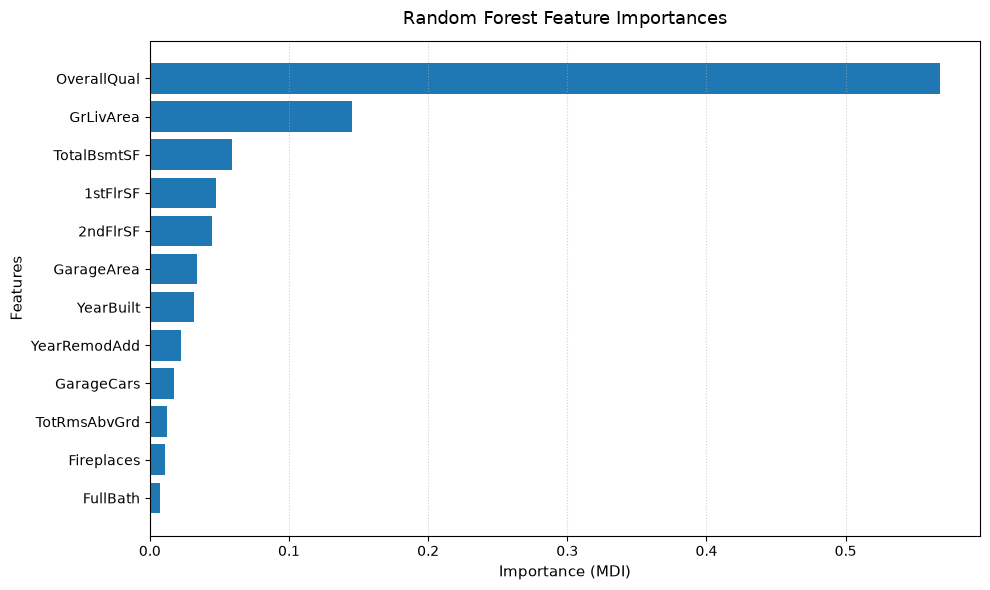

가장 높은 중요도를 가진 특성: 'OverallQual' (비중: 56.8166%)


In [6]:
# TODO
import matplotlib.pyplot as plt
import pandas as pd

# 1~2. 특성명과 중요도를 매핑하여 DataFrame 생성
fi_df = pd.DataFrame(
    {"특성": features, "중요도": rf.feature_importances_}
)

# 3. 중요도 기준 내림차순 정렬
fi_df = fi_df.sort_values(by="중요도", ascending=False).reset_index(drop=True)

print("=== 특성 중요도 (Feature Importance) ===")
display(fi_df.style.format({"중요도": "{:.4f}"}))

# 4. 막대그래프 시각화 (가독성을 위해 수평 막대그래프로 정렬)
plt.figure(figsize=(10, 6))
plt.barh(fi_df["특성"][::-1], fi_df["중요도"][::-1], color="tab:blue")
plt.title("Random Forest Feature Importances", fontsize=13, pad=12)
plt.xlabel("Importance (MDI)", fontsize=11)
plt.ylabel("Features", fontsize=11)
plt.grid(axis="x", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 5. 가장 높은 중요도를 가진 특성 출력
top_feature = fi_df.iloc[0]["특성"]
top_importance = fi_df.iloc[0]["중요도"]
print(f"가장 높은 중요도를 가진 특성: '{top_feature}' (비중: {top_importance:.4%})")

###
- OverallQual의 막대가 0.23까지 나타나있고, GrLivArea가 0.17이라는 것은 품질과 지상 면적이 약 40%정도의 설명력을 가지고 있다는 것으로 해석할 수 있다.
- 이 두 가지 지표로 전체 중요도의 40% 정도를 차지하기 때문에 가격변동(Y) 중 40%에 대해서 중요한 참고 데이터로 사용할 수 있다.
- 단 'R²이 40%다' 라고 설명하는 것은 적절하지 않다.
### 중요도 0.23을 어떻게 해석할 수 있는가?
- 가장 정확한 정의는 "랜덤포레스트의 불순도 기반 중요도에서 OverallQual이 약 23%정도 차지했다.".
- 잘못된 해석 : 품질이 집값의 23%를 결정한다. / 품질 1등급을 올리면 가격이 23% 상승한다.
### 낮은 중요도는 쓸모없는 변수라는 것을 의미하는가?
- 아니다. 해당 모델이 예측할 때 조금 덜 힌트를 얻었다는 뜻이다.
### 중요도 해석 한계점
- 불순도 기반 중요도가 가능한, 분할 지점이 많은 특성에 유리하게 작용
- 따라서 상관된 특성까리 중요도가 나뉘거나 쏠리는 현상이 있을 수 있음
###
- 현재 이 모델에서 중요도는 품질 등급과 지상 면적이 가장 크다.
- 이 부분은 이 입력구성과 학습 설정에서 모델이 예측을 위해 사용한 분할 정보의 상대적 기여를 의미한다.

### Q5. Feature Importance가 높다는 것이 그 변수가 주택가격의 원인이라는 뜻인가요?

**답변:** 아니오. 
- 중요도가 높다라는 것은 현재 모델이(설정 상태) 예측을 할 때 많이 활용했다는 의미이다.

--- 

# 과제 1. 나무 수와 예측 안정성 확인

`tree_counts = [1, 10, 50, 100]`을 사용하세요.

각 나무 수에서:
1. RandomForestRegressor 생성
2. `bootstrap=True`, `random_state=42`
3. Train 학습
4. Test R² 계산
5. DataFrame 정리
6. 나무 수에 따른 성능 변화 확인
7. 여러 예측의 평균과 분산 감소 관계 설명

In [8]:
# TODO
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 나무 수 후보 목록 정의
tree_counts = [1, 10, 50, 100]
results = []

# 1~4. 각 나무 수에 따른 모델 생성, 학습 및 Test R² 계산
for n_trees in tree_counts:
    rf = RandomForestRegressor(
        n_estimators=n_trees,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )
    # Train 학습
    rf.fit(X_train, y_train)
    
    # Test R² 계산
    y_pred = rf.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "나무 수 (n_estimators)": n_trees,
        "Test R²": r2
    })

# 5. DataFrame 정리 및 출력
results_df = pd.DataFrame(results)

print("=== 나무 수(n_estimators)에 따른 예측 성능 변화 ===")
display(results_df.style.format({"Test R²": "{:.4f}"}))

=== 나무 수(n_estimators)에 따른 예측 성능 변화 ===


,나무 수 (n_estimators),Test R²
0,1,0.7429
1,10,0.8836
2,50,0.8895
3,100,0.8901


### Q6. 나무 수를 늘리면 왜 예측이 더 안정적으로 변하나요?

**답변:**
- 나무 개수가 늘어나면 오차가 상쇄되어 전체 모델의 분산이 감소하기 떄문.

### Q7. 나무 수를 계속 늘리면 분산이 무한히 0으로 줄어드나요?

**답변:** 여기에 작성하세요.
- 아니오. 트리 간의 상관관계 때문에 하한값이 존재한다. 일정 나무 개수에서 분산의 감소가 정체하게된다.

# 실습 마무리
1. 부트스트랩 샘플링은 어떤 방식인가요?
- 원본 데이터셋에서 중복을 허용하여 같은 크기의 샘플을 추출(복원 추출)
###
2. Bagging 회귀에서는 여러 모델의 예측을 어떻게 합치나요?
- 여러 모델의 예측값의 평균
###
3. Random Forest가 Bagging에 추가하는 무작위성은 무엇인가요?
- 각 트리 분할에서 일부 피처만 무작위 후보로 사용
###
4. OOB 샘플은 평균적으로 약 몇 %인가요?
- 37%
###
5. Feature Importance가 높다는 것은 무엇을 의미하나요?
- 모델이 어떤 피쳐를 예측에 얼마나 많이 활용했는지
###
6. Bagging이 Decision Tree와 특히 잘 맞는 이유는 무엇인가요?
- Decision Tree는 기본적으로 분산이 큰 모델인데, 배경의 분산 감소 효과와 잘 맞음.